**Analysis of the relationship between the crime rate and median home value. It estimates how much house prices change when the crime rate increases by 0.01 given all things being equal**

Importing all the required packages

pandas - For handling the dataset  
numpy - Provides numerical operations  
matplotlib & seaborn - For data visualization  
sklearn.linear_model.LinearRegression - To build the linear regression model  
train_test_split - Splits the data into training and testing sets  
mean_squared_error & r2_score - To evaluate model performance  

In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score

**Data Loadinng**

Reading the csv file using read_csv from pandas

In [16]:
datafile = 'data\houseprice.csv'
df = pd.read_csv(datafile)

Using df.info() to show the data types and missing values.

In [17]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 506 entries, 0 to 505
Data columns (total 13 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   crime rate                       506 non-null    float64
 1   residential land zone            506 non-null    float64
 2   business acres                   506 non-null    float64
 3   Charles River                    506 non-null    int64  
 4   nitric oxides                    506 non-null    float64
 5   number of rooms                  506 non-null    float64
 6   age                              506 non-null    float64
 7   distances to employment centres  506 non-null    float64
 8   accessibility to highways        506 non-null    int64  
 9   property-tax                     506 non-null    int64  
 10  pupil-teacher ratio              506 non-null    float64
 11  lower income levels              506 non-null    float64
 12  Median Home Value     

Using df.head() to display the first 5 rows.

In [18]:
display(df.head())

,crime rate,residential land zone,business acres,Charles River,nitric oxides,number of rooms,age,distances to employment centres,accessibility to highways,property-tax,pupil-teacher ratio,lower income levels,Median Home Value
0,0.00632,18.0,2.31,0,0.538,6.575,65.2,4.0900,1,296,15.3,4.98,24.0
1,0.02731,0.0,7.07,0,0.469,6.421,78.9,4.9671,2,242,17.8,9.14,21.6
2,0.02729,0.0,7.07,0,0.469,7.185,61.1,4.9671,2,242,17.8,4.03,34.7
3,0.03237,0.0,2.18,0,0.458,6.998,45.8,6.0622,3,222,18.7,2.94,33.4
4,0.06905,0.0,2.18,0,0.458,7.147,54.2,6.0622,3,222,18.7,5.33,36.2


Considering all the values are equal and home value is only dependent on the crime rate.  
Independent variable (X) - Crime rate.  
Dependent variable (y) - Median home value.

In [19]:
X = df[['crime rate']]
y = df['Median Home Value']

**Spliting the data into training and testing Sets**

Training dataset - 80% of the data total dataset  
Testing dataset - 20% of the data total dataset  
random_state=42 ensures reproducibility

In [20]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

**Train the Linear Regression Model**

Creates and fits a linear regression model  
Finds the best-fit line to predict house prices based on crime rate  

In [21]:
model = LinearRegression()
model.fit(X_train, y_train)

LinearRegression()

**Extract the Slope**

model.coef_ gives the slope of the regression line.  
The slope tells us how much house prices change for every 1 unit increase in crime rate.  
Multiplying by 0.01 gives the change in house prices when crime rate increases by 0.01.  

In [22]:
slope = model.coef_[0]
change_per_0_01 = slope * 0.01

**Make Predictions and Evaluate the Model**

y_pred = model.predict(X_test) generates predictions.


In [23]:
y_pred = model.predict(X_test)

MSE (Mean Squared Error): Measures how far predictions are from actual values.
R² Score: Measures how well the model explains the data (closer to 1 is better).

In [24]:
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

Prints the impact of a 0.01 increase in crime rate on house prices.

In [25]:
print(f"For every 0.01 increase in the crime rate, the median house price {'decreases' if slope < 0 else 'increases'} by {abs(change_per_0_01):.8f} dollars.")
print(f"Mean Squared Error: {mse:.2f}")
print(f"R-squared: {r2:.2f}")

For every 0.01 increase in the crime rate, the median house price decreases by 0.00399667 dollars.
Mean Squared Error: 61.69
R-squared: 0.16


**Visualizing the Relationship**

Scatter plot: Shows actual house prices vs. crime rate.
Regression line: Red line represents the model’s predictions.
Legend & labels: Make the graph easy to understand.

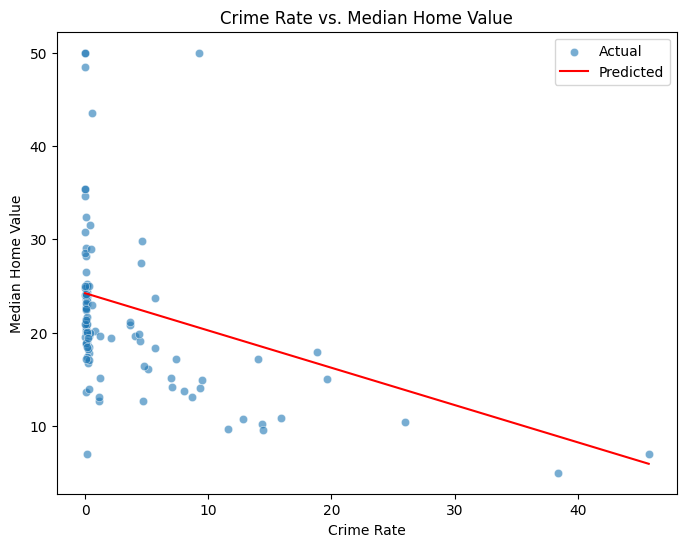

In [26]:
plt.figure(figsize=(8,6))
sns.scatterplot(x=X_test['crime rate'], y=y_test, label="Actual", alpha=0.6)
sns.lineplot(x=X_test['crime rate'], y=y_pred, color='red', label="Predicted")
plt.xlabel("Crime Rate")
plt.ylabel("Median Home Value")
plt.title("Crime Rate vs. Median Home Value")
plt.legend()
plt.show()

**Summary**

The model estimates how house prices change as the crime rate fluctuates.  
Higher crime rates tend to negatively impact property values.  
The regression model provides an approximate prediction of housing prices based on crime rate data.  